# Exploratory Data Analysis (EDA)

The first step in any machine learning project is to understand the data.

In this notebook, we will:

- Inspect the dataset structure
- Explore the target variable
- Identify relationships between features and sale price
- Investigate missing values
- Highlight potential feature engineering opportunities


## Import libraries

First, import the libraries used throughout the analysis.

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()

## Load the data

The competition provides separate training and test datasets. The training dataset contains the target variable (`SalePrice`), while the test dataset contains only the predictor variables.

We load both datasets, inspect their dimensions, check for duplicated rows, check column names etc.

In [2]:
df_test = pd.read_csv("data/test.csv")
df_train = pd.read_csv("data/train.csv")

print(
f"""
--------------------
Train set:

{df_train.shape[0]} rows
{df_train.duplicated().sum()} duplicated rows
{df_train.shape[1]} columns
--------------------
Test set:

{df_test.shape[0]} rows
{df_test.duplicated().sum()} duplicated rows
{df_test.shape[1]} columns
--------------------
Columns train/test:
{[column for column in df_train.columns if column in df_test.columns]}

Target variable (only in test):
{[column for column in df_train.columns if column not in df_test.columns]}
--------------------
"""
)


--------------------
Train set:

1460 rows
0 duplicated rows
81 columns
--------------------
Test set:

1459 rows
0 duplicated rows
80 columns
--------------------
Columns train/test:
['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrB

In [3]:
df_train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
df_test.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


## Understanding the target variable

Apart from the `SalePrice` column, which is missing from the `df_test` dataset, the other columns are all the same. The sale price is, of course, our target variable, i.e., the thing we will have to create a model to find out base on the other features.

Because this is a regression problem, the target variable deserves special attention. Let's inspect the distribution of house prices.

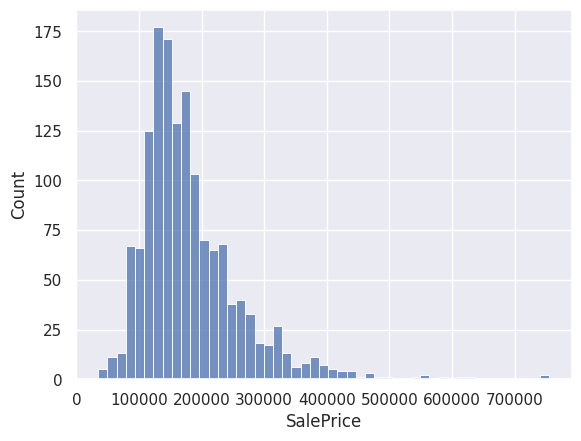

In [5]:
# Histogram
sns.histplot(df_train.get("SalePrice"))
plt.show()

As seen on the histogram above, the target feature `SalePrice` is right-skewed. In such cases, it is useful to perform a log transformation on this feature. After this transformation, the distribution closer resembles a normal distribution.

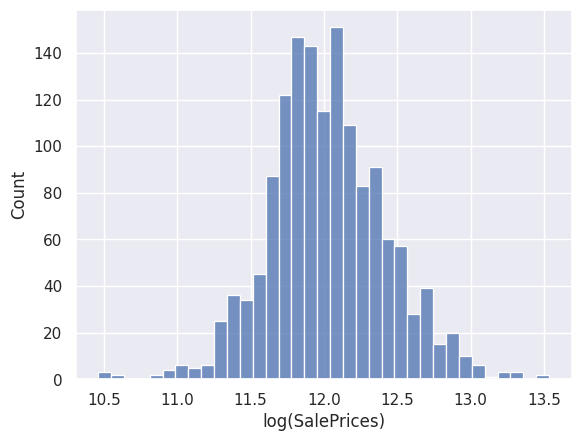

In [6]:
# Histogram log
sns.histplot(np.log1p(df_train.get("SalePrice")))
plt.xlabel("log(SalePrices)")
plt.show()

It is also useful to check for outliers in the house prices.

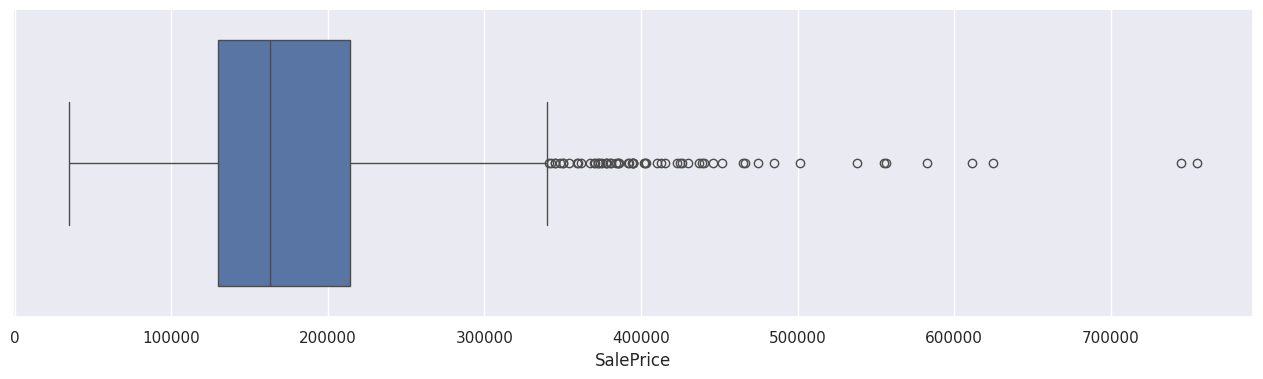

In [7]:
# Boxplot
plt.figure(figsize=(16, 4))
sns.boxplot(df_train["SalePrice"], orient='h')
plt.xlabel("SalePrice")
plt.show()

There are outliers and we will have to deal with them later. Now let's go for the other features.

## Combining train and test data

Many preprocessing steps must be applied consistently to both datasets. For exploratory purposes, it is therefore useful to temporarily combine the predictor variables from the training and test sets into a single dataframe.

The target variable (`SalePrice`) is excluded because it is only available in the training data.

In [8]:
# All features minus the tareget
features = df_test.columns

# Train/Test split
df_train["IsTrainSet"] = True
df_test["IsTrainSet"] = False

df_full = pd.concat(
    [df_train, df_test],
    axis=0,
    ignore_index=True
)

print(
    f"""
    Full dataset ( train + test ):

    {df_full.shape[0]} rows
    {df_full.duplicated().sum()} duplicated rows
    {df_full.shape[1]} columns
    """
)


    Full dataset ( train + test ):

    2919 rows
    0 duplicated rows
    82 columns
    


In order to start getting a feel for the data we have in our hands, we can use `info()` and `describe()` to learn about data types, missing data, and overall statistical metrics such as mean, median, max, min etc. While trying to understand the data, it is also very helpful to look at the [`data_description.txt`](data/data_description.txt) file in the `data` directory of this repository.

In [9]:
# Data types and Non-null counts
df_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2919 entries, 0 to 2918
Data columns (total 82 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             2919 non-null   int64  
 1   MSSubClass     2919 non-null   int64  
 2   MSZoning       2915 non-null   object 
 3   LotFrontage    2433 non-null   float64
 4   LotArea        2919 non-null   int64  
 5   Street         2919 non-null   object 
 6   Alley          198 non-null    object 
 7   LotShape       2919 non-null   object 
 8   LandContour    2919 non-null   object 
 9   Utilities      2917 non-null   object 
 10  LotConfig      2919 non-null   object 
 11  LandSlope      2919 non-null   object 
 12  Neighborhood   2919 non-null   object 
 13  Condition1     2919 non-null   object 
 14  Condition2     2919 non-null   object 
 15  BldgType       2919 non-null   object 
 16  HouseStyle     2919 non-null   object 
 17  OverallQual    2919 non-null   int64  
 18  OverallC

In [10]:
# Statistics
df_full.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,2919.000000,2919.000000,2433.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2896.000000,2918.000000,...,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,1460.000000
mean,1460.000000,57.137718,69.305795,10168.114080,6.089072,5.564577,1971.312778,1984.264474,102.201312,441.423235,...,93.709832,47.486811,23.098321,2.602261,16.062350,2.251799,50.825968,6.213087,2007.792737,180921.195890
std,842.787043,42.517628,23.344905,7886.996359,1.409947,1.113131,30.291442,20.894344,179.334253,455.610826,...,126.526589,67.575493,64.244246,25.188169,56.184365,35.663946,567.402211,2.714762,1.314964,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,730.500000,20.000000,59.000000,7478.000000,5.000000,5.000000,1953.500000,1965.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000,129975.000000
50%,1460.000000,50.000000,68.000000,9453.000000,6.000000,5.000000,1973.000000,1993.000000,0.000000,368.500000,...,0.000000,26.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,2189.500000,70.000000,80.000000,11570.000000,7.000000,6.000000,2001.000000,2004.000000,164.000000,733.000000,...,168.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,2919.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,1424.000000,742.000000,1012.000000,508.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000,755000.000000


## Histograms

As we did for the target variable, we can also look at the distributions for all numerical features.

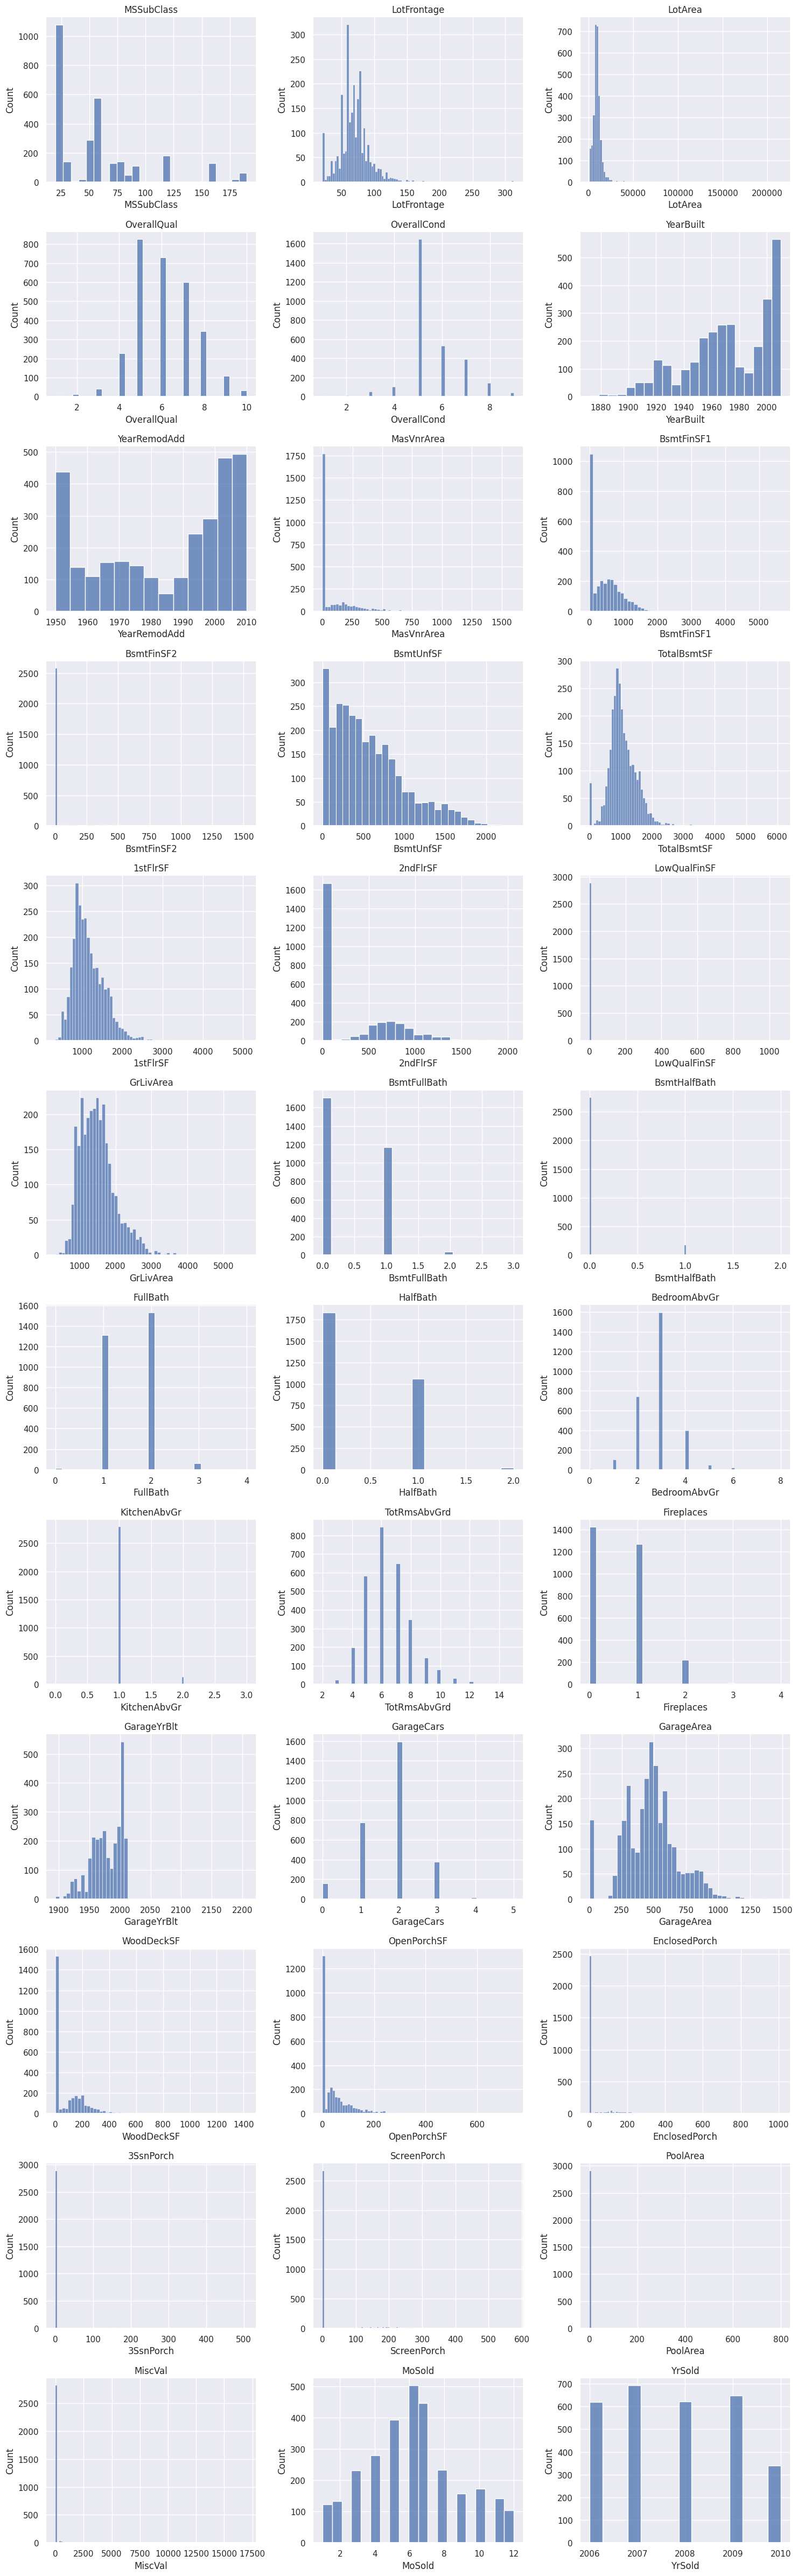

In [11]:
# Separate numerical features except for the target and Train/Test classification
df_numerical = df_full[[column for column in df_full.columns if column in features]].select_dtypes(exclude=['object'])
df_numerical = df_numerical.drop(["Id"], axis=1)

# Histograms for all features
cols = df_numerical.columns
n_cols = 3  # adjust as needed
n_rows = int(np.ceil(len(cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()  # make it 1D for easy indexing

for i, col in enumerate(cols):
    sns.histplot(df_numerical[col], ax=axes[i])
    axes[i].set_title(col)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

## Outliers

As we did for `SalePrice`, we can check all numerical data for outliers.

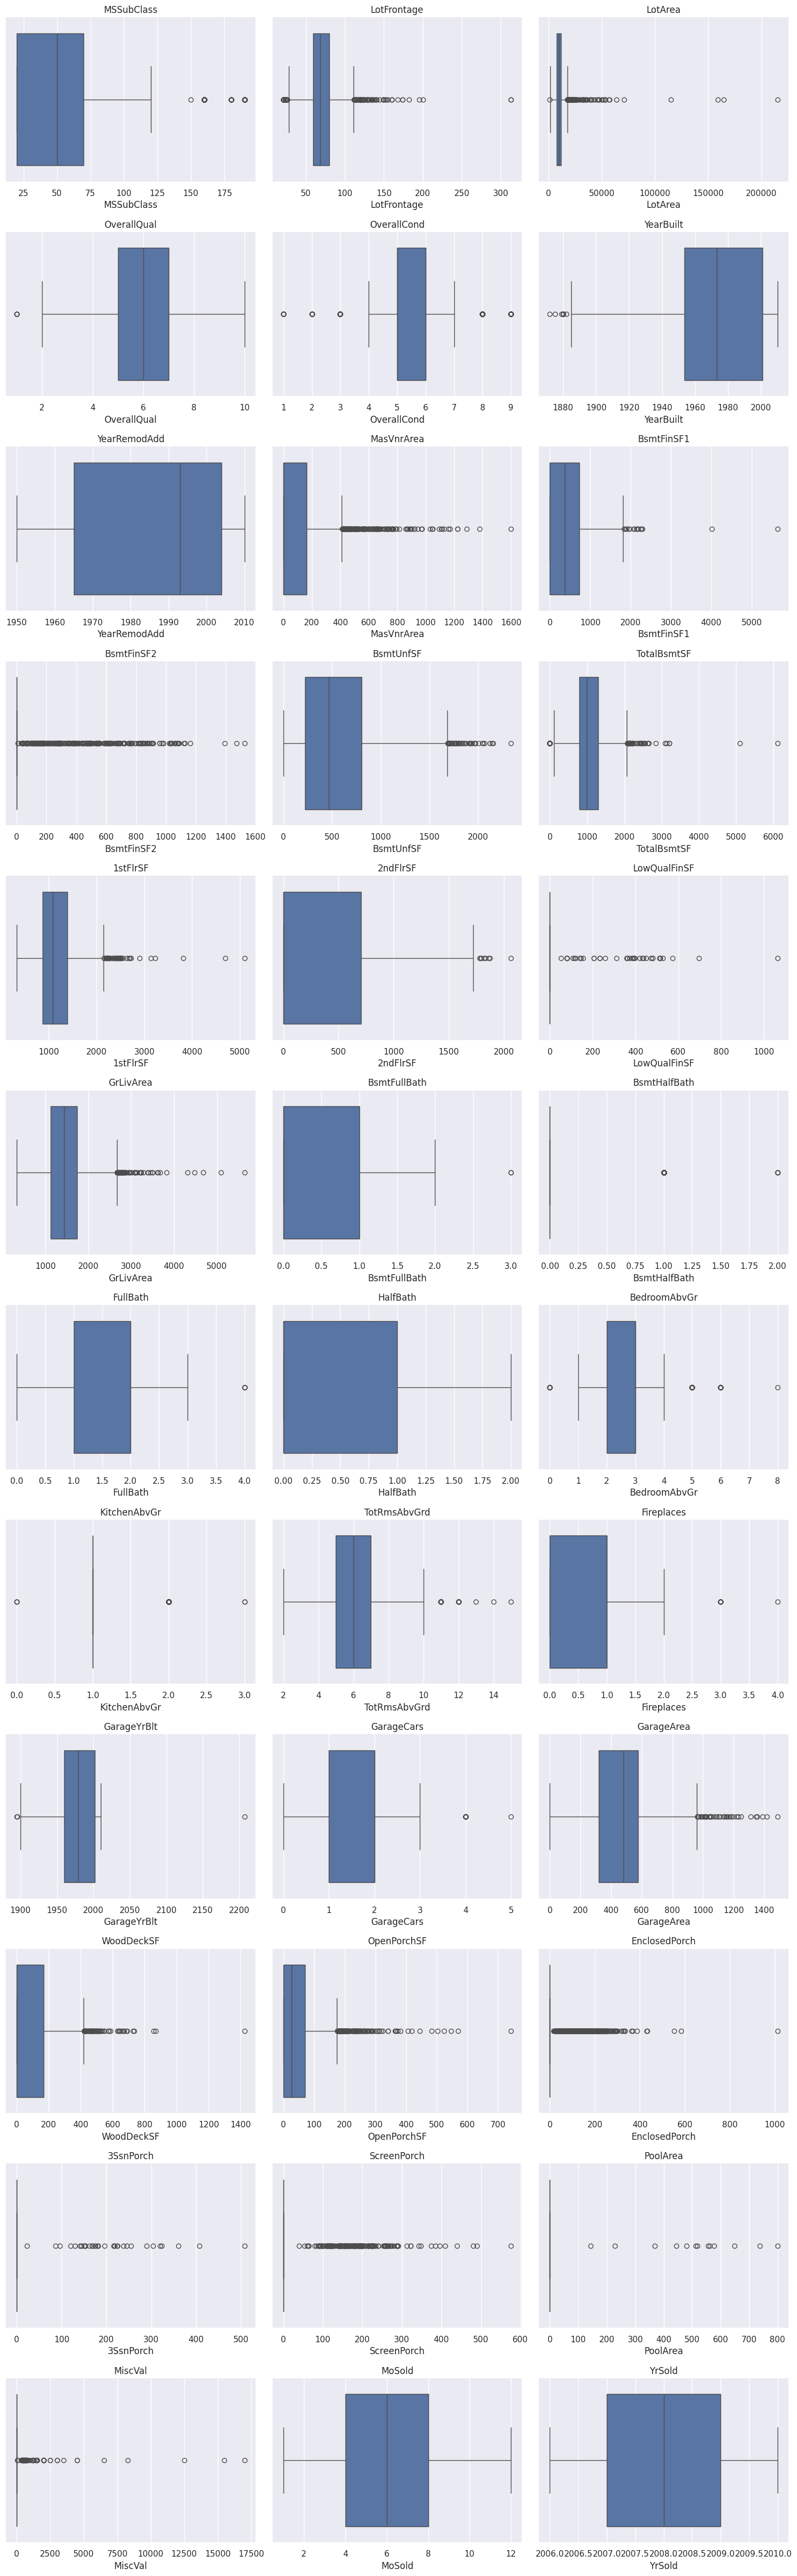

In [12]:
# Boxplots for all features
cols = df_numerical.columns
n_cols = 3  # adjust as needed
n_rows = int(np.ceil(len(cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()  # make it 1D for easy indexing

for i, col in enumerate(cols):
    sns.boxplot(df_numerical[col], ax=axes[i], orient="h")
    axes[i].set_title(col)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

From the images above and from the one we did for `SalePrice`, we see that there are outliers in the data. We will not delete the rows containing the outliers because by doing so we might lose some important information. The outliers will have to be handled later on the modeling stage.

## Missing Values

Missing data is one of the main challenges in this dataset. I always like to visually inspect how much of the data is missing before proceeding with the analysis.

Text(0.5, 1.0, 'Missing values heatmap')

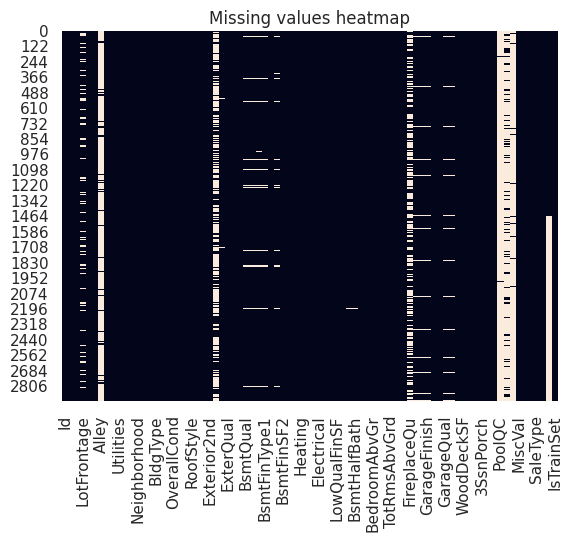

In [13]:
sns.heatmap(df_full.isnull(), cbar = False).set_title("Missing values heatmap")

Before deciding how to handle missing values, we first need to understand which features contain missing observations, how many values are missing, and whether missing values may carry information themselves.

We will evaluate each feature individually to determine the best imputation strategy, using [`data_description.txt`](data/data_description.txt) to guide our decisions:

- **For numerical features:** We will fill missing data with `0` (where it represents "None"), the mean, or the median/mode, depending on the distribution.
- **For categorical features:** We will impute missing data with `"None"` if it represents a missing attribute (e.g., no pool, no garage), or the mode if the data is truly missing at random.

Let's start by listing all features in descending order by the amount of missing values.

In [25]:
# All features with missing values
df_missing = df_full[features].isnull().sum().sort_values(ascending=False)
df_missing = df_missing.loc[df_missing.values > 0]
df_missing

PoolQC          2909
MiscFeature     2814
Alley           2721
Fence           2348
MasVnrType      1766
FireplaceQu     1420
LotFrontage      486
GarageYrBlt      159
GarageCond       159
GarageFinish     159
GarageQual       159
GarageType       157
BsmtCond          82
BsmtExposure      82
BsmtQual          81
BsmtFinType2      80
BsmtFinType1      79
MasVnrArea        23
MSZoning           4
BsmtHalfBath       2
Utilities          2
Functional         2
BsmtFullBath       2
BsmtFinSF1         1
Exterior1st        1
TotalBsmtSF        1
BsmtUnfSF          1
BsmtFinSF2         1
SaleType           1
KitchenQual        1
GarageCars         1
GarageArea         1
Electrical         1
Exterior2nd        1
dtype: int64

It will be usefull to separate the categorical from the numerical data.

### Categorical features



In [26]:
# Only categorical features
categorical_features = [column for column in features if column not in df_numerical.columns]
df_missing_categorical = df_full[categorical_features].isnull().sum().sort_values(ascending=False)
df_missing_categorical = df_missing_categorical.loc[df_missing_categorical.values > 0]
df_missing_categorical

PoolQC          2909
MiscFeature     2814
Alley           2721
Fence           2348
MasVnrType      1766
FireplaceQu     1420
GarageCond       159
GarageFinish     159
GarageQual       159
GarageType       157
BsmtCond          82
BsmtExposure      82
BsmtQual          81
BsmtFinType2      80
BsmtFinType1      79
MSZoning           4
Functional         2
Utilities          2
Exterior1st        1
Exterior2nd        1
KitchenQual        1
SaleType           1
Electrical         1
dtype: int64

In [27]:
# Unique values and value counts
for column in df_missing_categorical.index:
    print("-"*30)
    print(df_full[column].value_counts(dropna=False))
print("-"*30)

------------------------------
PoolQC
NaN    2909
Ex        4
Gd        4
Fa        2
Name: count, dtype: int64
------------------------------
MiscFeature
NaN     2814
Shed      95
Gar2       5
Othr       4
TenC       1
Name: count, dtype: int64
------------------------------
Alley
NaN     2721
Grvl     120
Pave      78
Name: count, dtype: int64
------------------------------
Fence
NaN      2348
MnPrv     329
GdPrv     118
GdWo      112
MnWw       12
Name: count, dtype: int64
------------------------------
MasVnrType
NaN        1766
BrkFace     879
Stone       249
BrkCmn       25
Name: count, dtype: int64
------------------------------
FireplaceQu
NaN    1420
Gd      744
TA      592
Fa       74
Po       46
Ex       43
Name: count, dtype: int64
------------------------------
GarageCond
TA     2654
NaN     159
Fa       74
Gd       15
Po       14
Ex        3
Name: count, dtype: int64
------------------------------
GarageFinish
Unf    1230
RFn     811
Fin     719
NaN     159
Name: count, d

As we see, almost all of the data in `PoolQC` are missing. And from  we see this refers to "Pool Quality". This means most of the houses do not have a pool. This missing value actually carries helpfull information. The same happens for all the categorical features for which the [`data_description.txt`](data/data_description.txt) file say that `NA` stands for "None" or "This house does not have this item". For features of this type we fill `NA` values with the `str` value "None".

Some features contain only a handful of missing values and exhibit a strongly dominant category. For example, most observations in `SaleType` are labeled `"WD"`. For these variables, missing values are replaced with the mode. The mode is computed from the training data and subsequently applied to both datasets to ensure a consistent preprocessing procedure while avoiding information leakage.

For example,

- `Exterior1st`: Exterior covering on house. It's reasonable to think all houses have at some kind of exterior covering. So, for the first material we fill the only missing value with the mode which is Vinyl Siding.
- `Exterior2nd`: Exterior covering on house (if more than one material). As it is possible that there is no second material for the exterior covering, we fill the only missing value with "None".


In [28]:
# Fill with "None"
list_na_is_none = [
    "PoolQC",
    "MiscFeature",
    "Alley",
    "Fence",
    "MasVnrType",
    "FireplaceQu",
    "GarageCond",
    "GarageFinish",
    "GarageQual",
    "GarageType",
    "BsmtCond",
    "BsmtExposure",
    "BsmtQual",
    "BsmtFinType2",
    "BsmtFinType1",
    "Exterior2nd",
]
for column in list_na_is_none:
    df_full[column] = df_full[column].fillna("None")

# Fill with the mode
list_na_is_mode = [
    "MSZoning",
    "Functional",
    "Utilities",
    "KitchenQual",
    "SaleType",
    "Electrical",
    "Exterior1st",
]
for column in list_na_is_mode:
    fill_with_mode = df_full.loc[df_full["IsTrainSet"], column].mode()[0]
    df_full[column] = df_full[column].fillna(fill_with_mode)


### Numerical features

In [29]:
# Only numerical features
numerical_columns = [column for column in df_numerical]
df_missing_numerical = df_full[numerical_columns].isnull().sum().sort_values(ascending=False)
df_missing_numerical = df_missing_numerical.loc[df_missing_numerical.values > 0]
df_missing_numerical

LotFrontage     486
GarageYrBlt     159
MasVnrArea       23
BsmtFullBath      2
BsmtHalfBath      2
GarageCars        1
BsmtFinSF2        1
GarageArea        1
TotalBsmtSF       1
BsmtFinSF1        1
BsmtUnfSF         1
dtype: int64

In [30]:
# Unique values and value counts
for column in df_missing_numerical.index:
    print("-"*30)
    print(df_full[column].value_counts(dropna=False))
print("-"*30)

------------------------------
LotFrontage
NaN      486
60.0     276
80.0     137
70.0     133
50.0     117
        ... 
155.0      1
126.0      1
200.0      1
131.0      1
133.0      1
Name: count, Length: 129, dtype: int64
------------------------------
GarageYrBlt
NaN       159
2005.0    142
2006.0    115
2007.0    115
2004.0     99
         ... 
1896.0      1
1895.0      1
2207.0      1
1943.0      1
1919.0      1
Name: count, Length: 104, dtype: int64
------------------------------
MasVnrArea
0.0      1738
NaN        23
120.0      15
176.0      13
200.0      13
         ... 
355.0       1
405.0       1
327.0       1
257.0       1
382.0       1
Name: count, Length: 445, dtype: int64
------------------------------
BsmtFullBath
0.0    1705
1.0    1172
2.0      38
3.0       2
NaN       2
Name: count, dtype: int64
------------------------------
BsmtHalfBath
0.0    2742
1.0     171
2.0       4
NaN       2
Name: count, dtype: int64
------------------------------
GarageCars
2.0    1594
1.

Most numerical features with missing values describe optional property characteristics, such as basements, garages, or masonry veneer. In these cases, a missing value generally indicates the absence of the corresponding feature, making `0` a meaningful replacement.

Two variables deserve special attention: `LotFrontage` and `GarageYrBlt`. For `LotFrontage`, a missing value does not imply zero street frontage. Likewise, `GarageYrBlt` is missing when a garage is absent rather than because the construction year is zero. More sophisticated imputation strategies could therefore be justified for these variables.

However, the number of missing values is relatively small compared to the size of the dataset, and many of the affected variables naturally admit a value of `0`. To keep the preprocessing pipeline simple and consistent, we will replace all remaining numerical missing values with `0`.

In [31]:
# Fill missing values with 0
for column in df_missing_numerical.index:
    df_full[column] = df_full[column].fillna(0)

Inspecting the value counts also revealed a likely data entry error. The variable `GarageYrBlt` contains a value of `2207`, which is clearly implausible given the context of the dataset. Since this year differs from `2007` by only a single digit and all other observations fall within a realistic range of construction years, we treat it as a typo and replace it with `2007`, which appears to be the most likely intended value.

In [32]:
df_full["GarageYrBlt"] = df_full["GarageYrBlt"].replace(2207, 2007)

## Numerical features and the target variable

One of the main objectives of exploratory data analysis is to identify which features appear to be related to the target variable. For numerical features, a simple way to do this is through scatterplots.

The plots below compare each numerical feature against `SalePrice`. While these visualizations do not provide a quantitative measure of association, they can reveal trends, outliers, nonlinear relationships, and other patterns that may be useful for subsequent modeling and feature engineering.

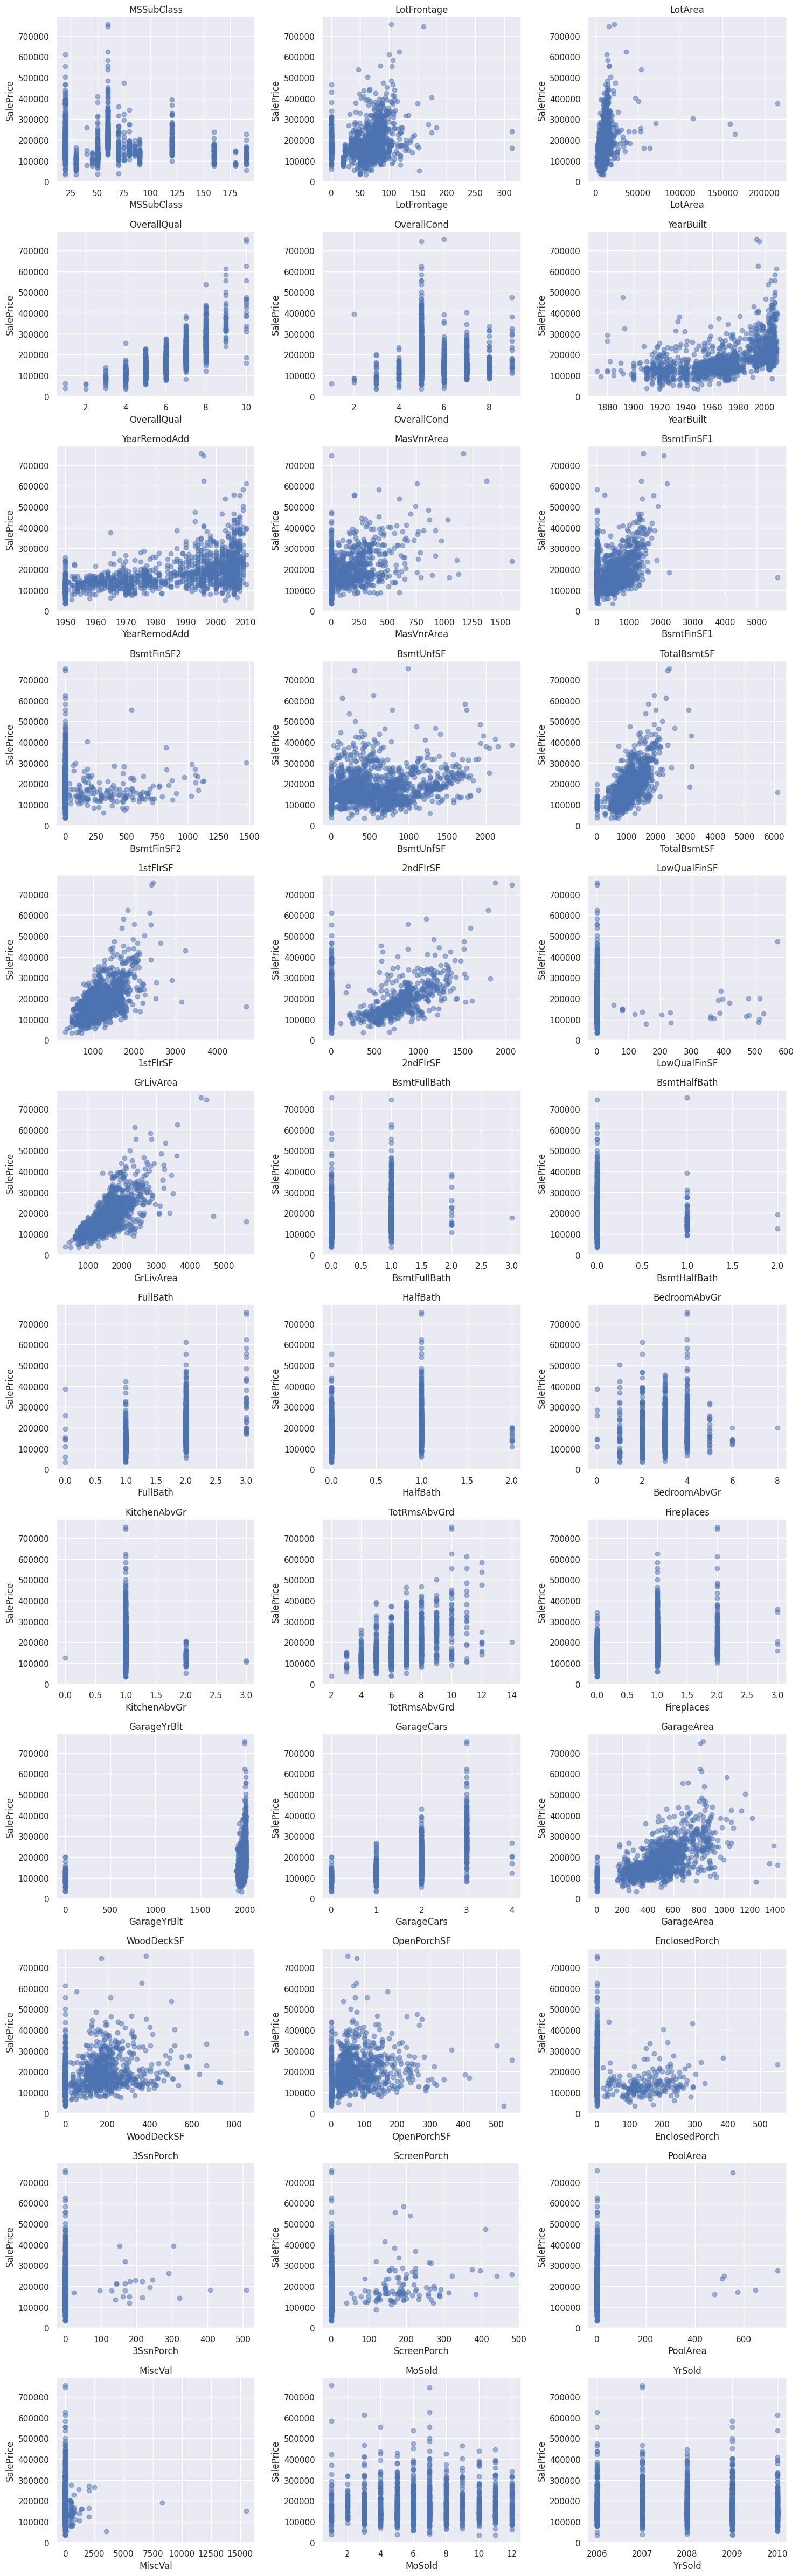

In [33]:
# Re-split train/test sets:
# Train set
df_train = df_full.loc[df_full["IsTrainSet"]]
X_train = df_train.drop(columns=["SalePrice", "IsTrainSet"])
y_train = df_full.loc[df_full["IsTrainSet"], "SalePrice"]
# Test set
X_test = df_full.loc[~df_full["IsTrainSet"]]

# Scatterplots for all features
cols = df_numerical.columns
n_cols = 3
n_rows = int(np.ceil(len(cols) / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(5 * n_cols, 4 * n_rows)
)

axes = axes.flatten()
for i, col in enumerate(cols):
    axes[i].scatter(
        X_train[col],
        y_train,
        alpha=0.5
    )

    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("SalePrice")

# Hide unused axes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

## Correlation matrix

The scatterplots provide a qualitative view of the relationship between individual features and the target variable. We can complement this analysis by computing the correlation matrix for the numerical features.

The correlation coefficient measures the strength and direction of a linear relationship between two variables. Values close to `1` indicate a strong positive association, values close to `-1` indicate a strong negative association, and values near `0` suggest little or no linear relationship.

The heatmap below highlights both the features most strongly associated with `SalePrice` and potential correlations between predictors that may indicate redundancy or multicollinearity.

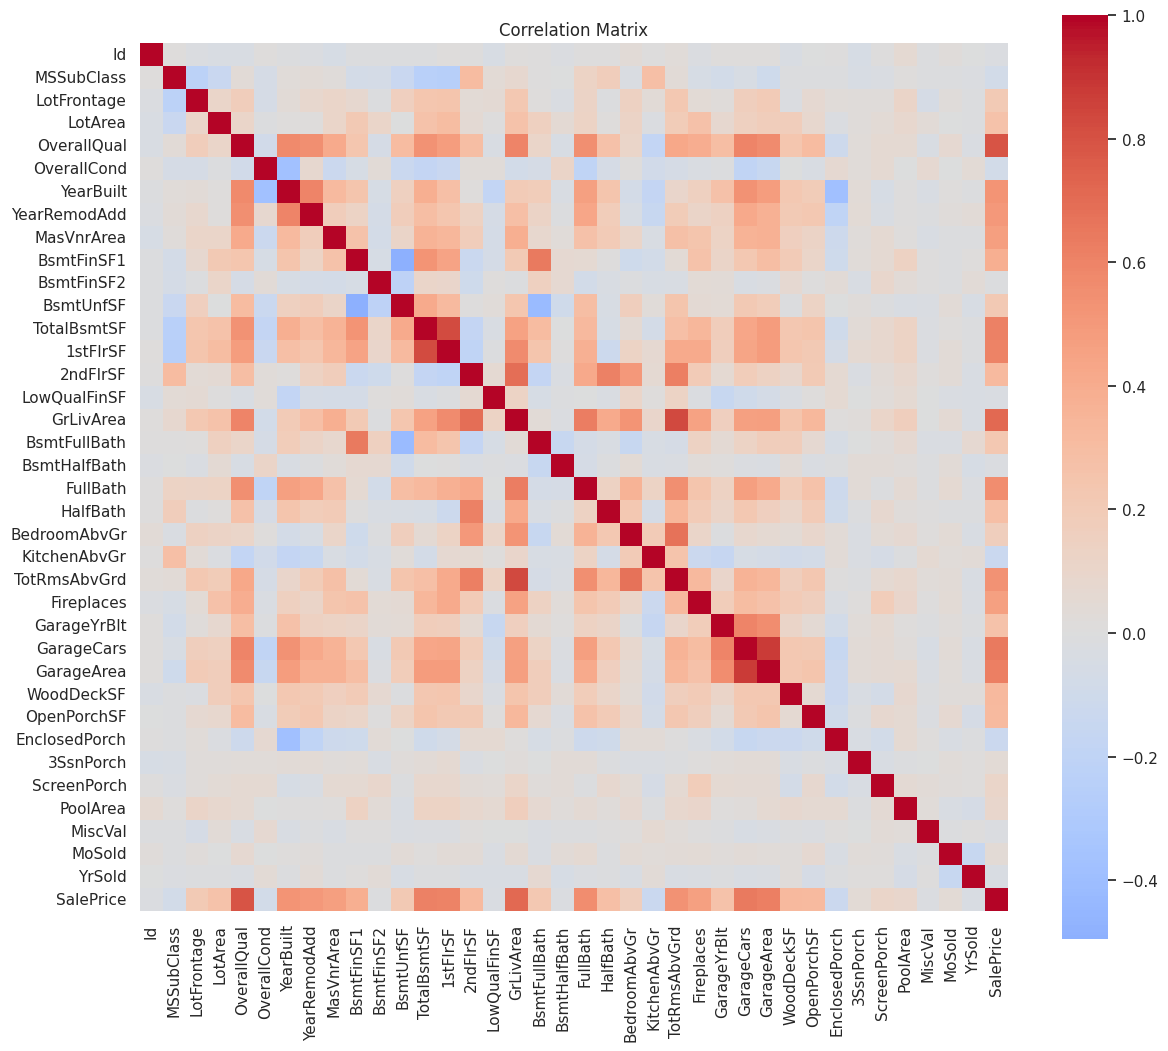

In [34]:
corr = df_train.select_dtypes(include="number").corr()

plt.figure(figsize=(14, 12))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    square=True
)

plt.title("Correlation Matrix")
plt.show()

## Save the processed dataset

At this stage, all identified data quality issues and missing values have been addressed. To avoid repeating these preprocessing steps in subsequent notebooks, we save the resulting dataset to disk.

The following notebook will build upon this dataset to perform feature engineering and prepare the data for machine learning models.

In [35]:
# Save dataframe in parquet format to preserve data types
df_full.to_parquet("processed_data/eda.parquet")

## Summary

In this notebook, we explored the House Prices dataset and identified several important characteristics that will guide the remainder of the project.

Key findings include:

* The dataset contained a substantial number of missing values, many of which could be interpreted as the absence of a property characteristic and were handled accordingly.
* Several data quality issues were identified and addressed, including an implausible value in `GarageYrBlt`.
* Visual inspection and correlation analysis revealed strong relationships between `SalePrice` and features such as `OverallQual`, `GrLivArea`, garage-related attributes, and other measures of property size and quality.
* Several predictors are themselves strongly correlated, suggesting the presence of redundancy and potential multicollinearity among some numerical features.
* Both numerical and categorical variables appear to contain valuable predictive information and are likely to contribute to model performance.

At this stage, we have a solid understanding of the dataset and the main factors that influence house prices. However, additional preprocessing and feature engineering steps are still required before training machine learning models. In particular, we will need to encode categorical variables, transform skewed features, and construct new features that may improve predictive performance.

In the [next notebook](2_feature_engineering.ipynb), we will focus on feature engineering and preparing the dataset for modeling.